<a href="https://colab.research.google.com/github/jben-hun/pyground/blob/master/notebooks/neuralNetBackprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Backpropagation

## 1. Introduction

This is a simple implementation of the [multilayer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron) algorithm in [python3](https://www.python.org/) and [numpy](https://numpy.org/).

**Features**:
*   Arbitrary depth and shape
*   [Supports (mini-)batches](https://en.wikipedia.org/wiki/Stochastic_gradient_descent)
*   [L2 Loss / Mean Squared Error](https://en.wikipedia.org/wiki/Mean_squared_error#Loss_functio)
*   Validated by comparing outputs with the [TensorFlow](https://www.tensorflow.org/) deep learning framework

**Formulas used:**

\begin{equation}
    \begin{split}
        \text{Output of a neuron} & :
            neuron(x,w,b) = x*w+b \\
        \\
        \text{Derivative of a neuron w.r.t. its input} & :
            \frac{\partial neuron}{\partial x} = w \\
        \text{Derivative of a neuron w.r.t. its weight} & :
        \frac{\partial neuron}{\partial w} = x \\
        \text{Derivative of a neuron w.r.t. its bias} & :
        \frac{\partial neuron}{\partial b} = 1 \\
        \\
        \text{Output of ReLu} & :
        relu(x) =
        \begin{cases}
            x, & \text{if } x > 0\\
            0, & \text{otherwise}
        \end{cases} \\
        \\
        \text{Derivative of ReLu w.r.t. its input} & :
        \frac{\partial relu}{\partial x} =
            \begin{cases}
                1, & \text{if } x > 0\\
                0, & \text{if } x < 0\\
                0, & \text{if } x = 0 \text{ (undefined, 0 by convention)}
            \end{cases} \\
        \\
        \text{MSE} & :
            mse(output, labels) = \frac{1}{N}\sum{(output-labels)^2} \\
        \\
        \text{Derivative of MSE w.r.t. to predictions} & :
            \frac{\partial mse}{\partial output} = \frac{1}{2N}\sum{(output-labels)} \\
        \\
        \text{Sum rule} & :
        (f+g)'=f'+g'\\
        \\
        \text{Chain rule} & :
        \frac{\partial l_2}{\partial x}(x) =
        \frac{\partial l_2}{\partial l_1}(l_1) \cdot
        \frac{\partial l_1}{\partial x}(x) \\
        \\
        layer_1 \text{ input} & : x \\
        layer_1 \text{ output} & : l_1(x) \\
        layer_2 \text{ input} & : l_1(x) \\
        layer_2 \text{ output} & : l_2(l_1(x))
    \end{split}
\end{equation}

## 2. Implementation

In [1]:
import numpy as np
from numpy.random import default_rng

In [2]:
class Net:
    def __init__(self, layout):
        self.layers = []
        last_index = len(layout) - 2

        for index in range(last_index + 1):
            inputs = layout[index]
            outputs = layout[index + 1]
            self.layers.append(Layer(inputs, outputs))
            if index != last_index:
                self.layers.append(Relu())

        self.forward_data = [None] * (len(self.layers) + 1)
        self.backward_data = [None] * (len(self.layers) + 1)
        self.loss_value = None

    def forward(self, input_data):
        self.forward_data[0] = input_data

        for index in range(len(self.layers)):
            self.forward_data[index + 1] = self.layers[index].forward(
                self.forward_data[index])

    def backward(self, label_data, learning_rate):
        self.loss_value = self.calculate_loss(
            self.get_output(), label_data)
        
        self.backward_data[-1] = self.calculate_loss_gradient(
            self.get_output(), label_data)
        
        for index in reversed(range(1, len(self.backward_data))):
            self.backward_data[index - 1] = self.layers[index - 1].backward(
                self.forward_data[index - 1],
                self.backward_data[index],
                learning_rate)

    def forward_backward(self, input_data, label_data, learning_rate):
        self.forward(input_data)
        self.backward(label_data, learning_rate)

    def calculate_loss(self, output_value, label_data):
        return np.square(output_value - label_data).mean()

    def calculate_loss_gradient(self, output_value, label_data):
        output_size = label_data.shape[1]
        return 2 * (output_value - label_data) / output_size

    def get_output(self):
        return self.forward_data[-1]

    def get_loss(self):
        return self.loss_value

class Layer:
    def __init__(self, inputs, outputs):
        self.weights = rng.normal(scale=0.05, size=(inputs, outputs))
        self.biases = np.zeros(outputs)

    def forward(self, input_value):
        output_value = input_value @ self.weights + self.biases
        return output_value

    def backward(self, input_value, gradient_value, learning_rate):
        # "*" operator: chain rule
        # "sum" function: sum rule
        # (return value is computed before weights are updated)
        return_value = (self.weights[np.newaxis, :, :] *
                        gradient_value[:, np.newaxis, :]).sum(2)

        # averages of batch gradients

        self.weights += self.calculate_update(
            (input_value[:, :, np.newaxis] *
            gradient_value[:, np.newaxis, :]).mean(0),
            learning_rate)
        
        self.biases += self.calculate_update(
            gradient_value.mean(0),
            learning_rate)

        return return_value

    def calculate_update(self, gradient, learning_rate):
        return gradient * learning_rate * -1


class Relu:
    def forward(self, input_value):
        return np.clip(input_value, 0, None)

    def backward(self, input_value, gradient_value, learning_rate):
        # "*" operator: chain rule
        return (input_value > 0) * gradient_value

## 3. Comparison with TensorFlow

### 3.1. Wrappers for uniform handling of implemented and tensorflow models

In [3]:
import tensorflow as tf
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import tqdm.auto as tq

rng = default_rng(42)
sns.set(style="white")

In [4]:
class Wrapper:
    def __init__(self, name, layout, learning_rate, weight_initializer=None):
        self.__name=name
        self.__layout=layout
        pass

    def train_step(self, x, y):
        pass

    def get_loss(self, x, y):
        pass

    def get_outputs(self, x):
        pass

    @property
    def variables(self):
        pass

    @property
    def name(self):
        return self.__name

    @property
    def layout(self):
        return self.__layout


class NetWrapper(Wrapper):
    def __init__(self, name, layout, learning_rate, weight_initializer=None):
        super().__init__(name, layout, learning_rate, weight_initializer)

        self.learning_rate = learning_rate
        self.net = Net(layout)
        if weight_initializer == "ones":
            weight_initializer = lambda shape: np.ones(shape=shape)
            for layer in self.net.layers:
                if type(layer) is Layer:
                    layer.weights = weight_initializer(layer.weights.shape)
    
    def train_step(self, x, y):
        self.net.forward_backward(x, y, self.learning_rate)

    def get_loss(self, x, y):
        self.net.forward_backward(x, y, learning_rate=0)
        return self.net.get_loss()

    def get_outputs(self, x):
        self.net.forward(x)
        outputs = []
        for i, layer in enumerate(self.net.layers):
            if type(layer) is Relu:
                outputs.append(self.net.forward_data[i + 1])
        outputs.append(self.net.forward_data[-1])
        return outputs

    @property
    def variables(self):
        variables = {}
        c = 1
        for layer in self.net.layers:
            if type(layer) is Layer:
                variables[f"layer {c} weights"] = layer.weights
                variables[f"layer {c} biases"] = layer.biases
                c += 1
        return variables


class TfModelWrapper(Wrapper):
    def __init__(self, name, layout, learning_rate, weight_initializer=None):
        super().__init__(name, layout, learning_rate, weight_initializer)

        if weight_initializer == "ones":
            weight_initializer = tf.keras.initializers.Ones()
        else:
            weight_initializer = tf.keras.initializers.RandomNormal(
                stddev=0.05)

        inputs = tf.keras.Input(shape=(layout[0],), dtype="float64")

        previous_layer = inputs

        for layer_size in layout[1:-1]:
            layer = tf.keras.layers.Dense(
                layer_size, activation="relu",
                kernel_initializer=weight_initializer,
                bias_initializer=tf.keras.initializers.Zeros(),
                dtype="float64")(previous_layer)

            previous_layer = layer

        outputs = tf.keras.layers.Dense(
            layout[-1],
            kernel_initializer=weight_initializer,
            bias_initializer=tf.keras.initializers.Zeros(),
            dtype="float64")(previous_layer)

        self.model = tf.keras.Model(inputs=inputs, outputs=outputs)
        self.optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
        self.loss = tf.keras.losses.MeanSquaredError()

    def train_step(self, x, y):
        with tf.GradientTape() as tape:
            loss_value = self.loss(y, self.model(x, training=True))

        grads = tape.gradient(loss_value, self.model.trainable_weights)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_weights))
        
    def get_loss(self, x, y):
        return self.loss(y, self.model(x)).numpy()

    def get_outputs(self, x):
        outputs = []
        previous_output = x
        for layer in self.model.layers[1:]:
            previous_output = layer(previous_output)
            outputs.append(previous_output.numpy())
        return outputs

    @property    
    def variables(self):
        variables = {}
        for i, layer in enumerate(self.model.layers[1:]):
            w, b = layer.get_weights()
            variables[f"layer {i + 1} weights"] = w
            variables[f"layer {i + 1} biases"] = b
        return variables

### 3.2. Full training comparison

In [5]:
def wrapper_trainer(wrappers, x, y, batch_size, epochs):
    examples = len(x)

    results = {wrapper.name: {"epochs": [], "losses": [], "outputs": None}
               for wrapper in wrappers}

    for wrapper in wrappers:
        results[wrapper.name]["epochs"].append(0)
        results[wrapper.name]["losses"].append(wrapper.get_loss(x, y))

    for epoch in tq.trange(1, epochs + 1):
        permutation = rng.permutation(examples)
        x_shuffled = x[permutation]
        y_shuffled = y[permutation]

        for batch in range(examples // batch_size):
            x_batch = x_shuffled[batch * batch_size: (batch + 1) * batch_size]
            y_batch = y_shuffled[batch * batch_size: (batch + 1) * batch_size]

            for wrapper in wrappers:
                wrapper.train_step(x_batch, y_batch)

        for wrapper in wrappers:
            results[wrapper.name]["epochs"].append(epoch)
            results[wrapper.name]["losses"].append(wrapper.get_loss(x, y))

    for wrapper in wrappers:
        results[wrapper.name]["outputs"] = wrapper.get_outputs(x)

    return results

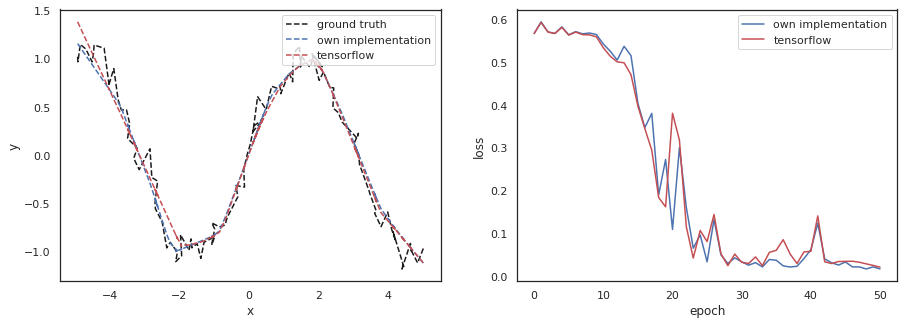

In [6]:
layout = [1, 32, 32, 1]
batch_size = 4
epochs = 50
learning_rate = 0.1

wrappers = (TfModelWrapper("tf", layout, learning_rate),
            NetWrapper("own", layout, learning_rate))

examples = 100

# square function
def f(x):
    # return x**2
    return np.sin(x)

x = np.linspace(-5, 5, examples)[:, np.newaxis]
y = f(x)

# noise
x += rng.normal(scale=0.1, size=x.shape)
y += rng.normal(scale=0.1, size=y.shape)

x_norm = (x - x.mean()) / x.std()

results = wrapper_trainer(
    wrappers=wrappers,
    x=x_norm,
    y=y,
    batch_size=batch_size,
    epochs=epochs)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(x, y, "k--", label="ground truth")
axs[0].plot(x, results["own"]["outputs"][-1], "b--", label="own implementation")
axs[0].plot(x, results["tf"]["outputs"][-1], "r--", label="tensorflow")
axs[0].set(xlabel="x", ylabel="y")
axs[0].legend()

axs[1].plot(results["own"]["epochs"], results["own"]["losses"], "b",
            label="own implementation")
axs[1].plot(results["tf"]["epochs"], results["tf"]["losses"], "r",
            label="tensorflow")
axs[1].set(xlabel="epoch", ylabel="loss")
axs[1].legend();

### 3.3. Step-by-step compatison of variables and outputs

In [7]:
def wrapper_debugger(wrappers, batch_size, steps):
    def values_close(a, b):
        tolerance = dict(rtol=1e-1, atol=0)  # 10% tolerance

        if isinstance(a, np.float64):
            return np.allclose(a, b, **tolerance)

        elif isinstance(a, list):
            for i in range(len(a)):
                if not np.allclose(a[i], b[i], **tolerance):
                    return False
            return True

        elif isinstance(a, dict):
            for k in a.keys():
                if not np.allclose(a[k], b[k], **tolerance):
                    return False
            return True

        else:
            assert False, "unhandled type"

    assert len(wrappers) == 2, "can only compare 2 wrappers"

    inputs = wrappers[0].layout[0]
    outputs = wrappers[0].layout[-1]
    for step in range(steps + 1):
        print(f"STEP {step}:")

        x = rng.integers(-1, 1, size=(batch_size, inputs), endpoint=True)
        y = rng.integers(-1, 1, size=(batch_size, outputs), endpoint=True)

        data = {}

        for wrapper in wrappers:
            if step != 0:
                wrapper.train_step(x, y)

            data[wrapper.name] = dict(
                loss=wrapper.get_loss(x, y),
                outputs=wrapper.get_outputs(x),
                variables=wrapper.variables)

        difference = False
        for key in tuple(data.values())[0].keys():
            values1 = tuple(data.values())[0][key]
            values2 = tuple(data.values())[1][key]
            if not values_close(values1, values2):
                difference = True
                print(f"{key} DIFFERENCE!")
                for name, datum in data.items():
                    print(name)
                    print(datum[key])
                    print()
        
        if difference:
            return
        else:
            print("OK")

In [8]:
layout = [3, 4, 5]
weight_initializer = "ones"
batch_size = 20
steps = 10
learning_rate = 1

wrappers = (TfModelWrapper("tf", layout, learning_rate, weight_initializer),
            NetWrapper("own", layout, learning_rate, weight_initializer))

wrapper_debugger(
    wrappers=wrappers,
    batch_size=batch_size,
    steps=steps)

STEP 0:
OK
STEP 1:
OK
STEP 2:
OK
STEP 3:
OK
STEP 4:
OK
STEP 5:
OK
STEP 6:
OK
STEP 7:
OK
STEP 8:
OK
STEP 9:
OK
STEP 10:
OK


## 4. Links

*   <https://colah.github.io/posts/2015-08-Backprop/>